## Prepare dataset

In [1]:
import os
from pathlib import Path

In [2]:
DATA_PATH = os.path.join('/data/galati/brain_data/ITKTubeTK/fold1', 'imagesTs')
OUT_DIR = DATA_PATH.replace('imagesTs', 'A2VpreproccTs')
DATASET_NAME = 'ITKTubeTK_A2V'

DATA_PATH = '/data/falcetta/LONDON_TEST/IMG'
OUT_DIR = DATA_PATH.replace('IMG', 'OUT')
DATASET_NAME = 'LONDON_TEST'
complete_flag = True


#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    return img_path.replace("imagesT", "brainT").replace(".nii.gz", "_brain_join_mask.nii.gz")
def img_path_to_vessel_path(img_path):
    return img_path.replace("imagesT", "labelsT")
def img_path_to_weight_path(img_path):
    return "ERROR"

# IF WE WANT TO DO EXPERIMENTS WITH COMPLETE VESSEL MASKS
def img_path_to_vessel_path_complete(img_path):
    vessel_path = img_path.replace("imagesT", "labelsT").replace(".nii.gz", "_COMPLETE_new.nii.gz")
    return vessel_path
def img_path_to_weight_path_complete(img_path):
    return "ERROR"

utils.img_path_to_brain_path = img_path_to_brain_path
if complete_flag:
    utils.img_path_to_weight_path = img_path_to_weight_path_complete
    utils.img_path_to_vessel_path = img_path_to_vessel_path_complete
else:
    utils.img_path_to_weight_path = img_path_to_weight_path 
    utils.img_path_to_vessel_path = img_path_to_vessel_path 

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = "^.*.nii.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = []

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

### Extract paths

In [3]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [4]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [5]:
for selected_pth in info["train"].paths:
    print(selected_pth)
#for selected_pth in info["test"].paths:
#    print(selected_pth)

/data/falcetta/LONDON_TEST/IMG/TOF_COW_tra.nii.gz
/data/falcetta/LONDON_TEST/IMG/TOF_COW_tra_SS.nii.gz


### Display examples

In [6]:
import random

from utils import print_bold, load_and_display_middle_slice

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 696 768 168   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.       0.260417 0.260417 0.6      0.       0.       0.       0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.09915166
quatern_c       : 0.0042077038
quatern_d       : 0.0004192699
qoffset_x       : -90.711235
qoffse

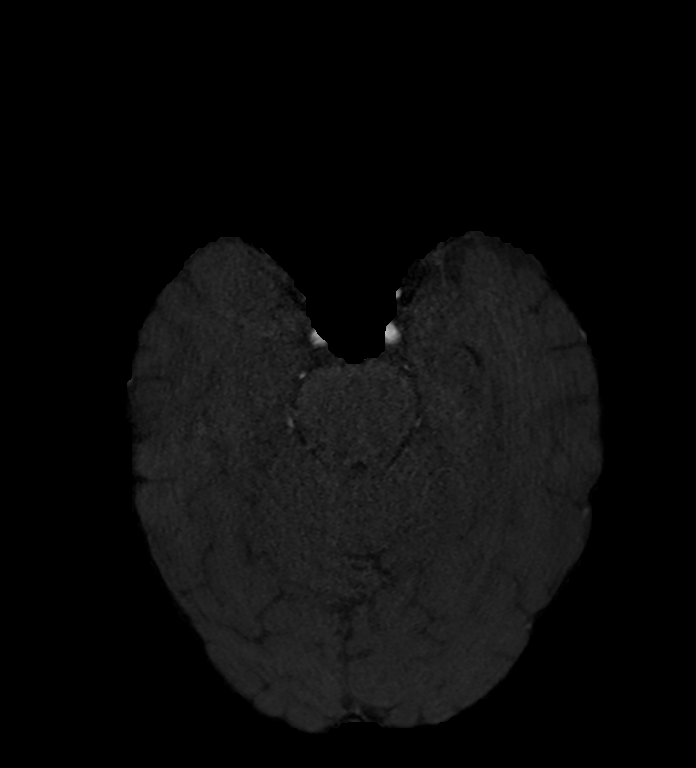

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 696 768 168   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.       0.260417 0.260417 0.6      0.022    0.       0.       0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=3.4;Time=114515.705'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.09915166
quatern_c       : 0.004207704
quatern_d       : 0.0004192699
qoffset_x    

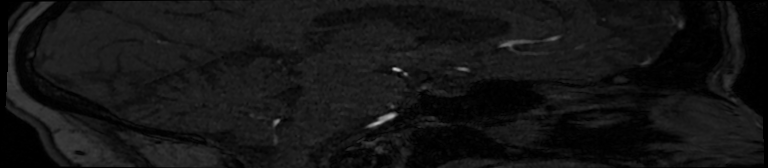

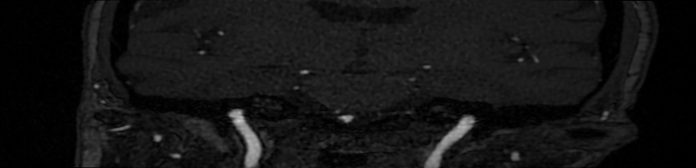

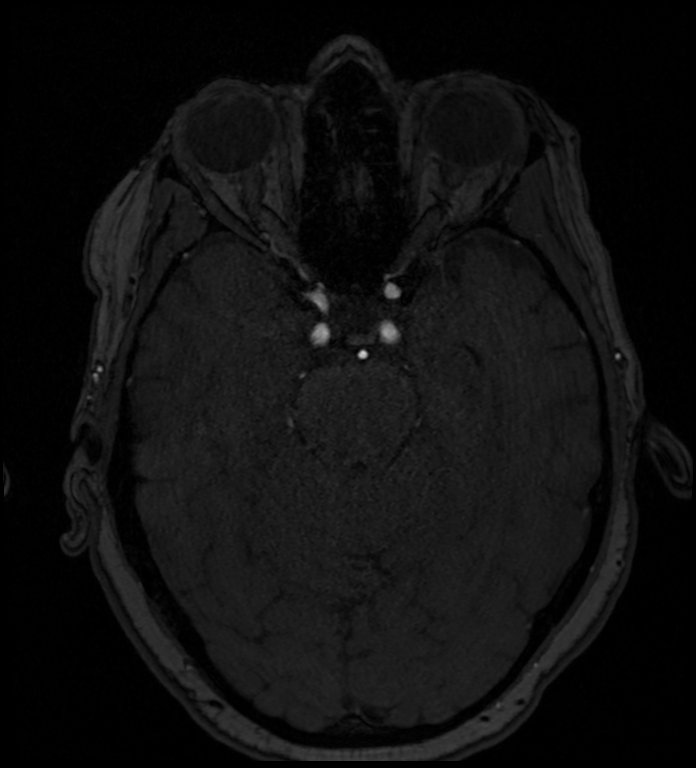

In [7]:
print_bold("[Example 01]")
random.seed(0)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(1)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [8]:
from utils import is_medical_volume

In total, there are

In [9]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

2

volumes. First, we discard the outliers:

In [10]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs), IMGs[:5]

(2,
 ['/data/falcetta/LONDON_TEST/IMG/TOF_COW_tra.nii.gz',
  '/data/falcetta/LONDON_TEST/IMG/TOF_COW_tra_SS.nii.gz'])

We have vessel annotations for

In [11]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]

if complete_flag:
    HAVE_VESSELs = [
        img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path_complete(img_path))
    ]

for selected_pth in HAVE_VESSELs:
    if complete_flag:
        print(selected_pth.split('/')[-1], '--->', img_path_to_vessel_path_complete(selected_pth).split('/')[-1])
    else:
        print(selected_pth.split('/')[-1], '--->', img_path_to_vessel_path(selected_pth).split('/')[-1])
len(HAVE_VESSELs)

0

of them. With a chosen ratio of 70-15-15, we select

In [12]:
COUNT_TEST = len(HAVE_VESSELs if VESSELs_REQUIRED else IMGs) * 15 // 100
COUNT_TEST

0

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [13]:
BRAIN_PATHs = [img_path_to_brain_path(img_path) for img_path in IMGs]

for bp in BRAIN_PATHs[:5]:
    print(bp)

/data/falcetta/LONDON_TEST/IMG/TOF_COW_tra_brain_join_mask.nii.gz
/data/falcetta/LONDON_TEST/IMG/TOF_COW_tra_SS_brain_join_mask.nii.gz


In [14]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

0

Finally, we randomly split our dataset. 

In [15]:
JUST_TEST=True

In [16]:
if JUST_TEST:
    TRAIN_IMGs = []
    VAL_IMGs = []
    TEST_IMGs = IMGs
    print(f"WARNING: You are selecting only the test set (#{len(TEST_IMGs)} Imgs).")
else:
    print("WARNING: You are selecting a subset of the dataset for training and validation.")

In [17]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Extract spacings and shapes

In [18]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [19]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [20]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [21]:
if JUST_TEST:
    display_info(info["test"], info["test"])
else:
    display_info(info["train"], info["val"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,2,336,[000.26 000.26 000.60],[000.26 000.26 000.60] - [000.26 000.26 000.60],[601.50 715.00 168.00],[507.00 662.00 168.00] - [696.00 768.00 168.00]
VAL,2,336,[000.26 000.26 000.60],[000.26 000.26 000.60] - [000.26 000.26 000.60],[601.50 715.00 168.00],[507.00 662.00 168.00] - [696.00 768.00 168.00]


In [23]:
import numpy as np

In [24]:
if JUST_TEST:
    SPACING = np.array([0.46875   , 0.46875   , 0.79999992])
else:
    SPACING = get_target_spacing(
        info["train"].spacings + info["val"].spacings,
        info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
)

SPACING

array([0.46875   , 0.46875   , 0.79999992])

In [25]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [26]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [27]:
import os

from utils import print_bold, preprocessing_loop

In [28]:
print_bold("Training")
preprocessing_loop(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING
)

print_bold("Validation")
preprocessing_loop(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING
)

print_bold("Testing")
preprocessing_loop(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING
)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


...

(696, 768, 168)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.260417 0.260417 0.6     ]
New shape: [387 427 126]
Resized shape: (387, 427, 126)
PASSED New shape: [512, 512]
New shape: [512 512 126]
Resized shape: (512, 512, 126)


 50%|█████     | 1/2 [00:31<00:31, 31.47s/it]

Slices processed: 126
(696, 768, 168)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.260417 0.260417 0.6     ]
New shape: [282 368 126]
Resized shape: (282, 368, 126)
PASSED New shape: [512, 512]
New shape: [512 512 126]
Resized shape: (512, 512, 126)


100%|██████████| 2/2 [00:54<00:00, 27.07s/it]

Slices processed: 252


In [29]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Outliers removal and slices extraction

In [30]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [31]:
import os

from utils import print_bold, extraction_loop, display_slice

In [32]:
print_bold("Training")
extraction_loop(
    info["train"],
    os.path.join(OUT_DIR,"slices", "train")
)

print_bold("Validation")
extraction_loop(
    info["val"],
    os.path.join(OUT_DIR,"slices", "val")
)

print_bold("Testing")
extraction_loop(
    info["test"],
    os.path.join(OUT_DIR,"slices", "test")
)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


100%|██████████| 2/2 [00:00<00:00,  6.14it/s]


In [33]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Intensity values analysis

In [37]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [38]:
import numpy as np

from utils import intensity_loop, display_intensity
from utils import get_percentile, display_clipped_slice, print_bold

Testing


100%|██████████| 2/2 [00:01<00:00,  1.31it/s]


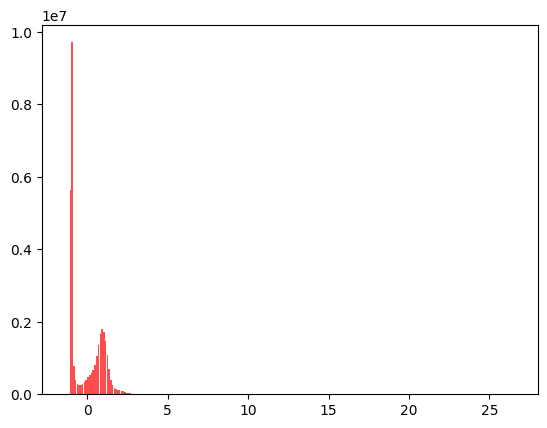

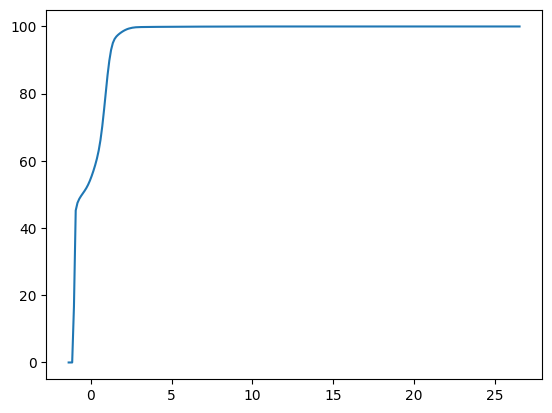

In [39]:
if JUST_TEST:
    print_bold("Testing")
    intensity_loop(
        info["test"],
        min_value=-1.375722615918066,
        max_value=26.655313787135135
    )
    display_intensity(info["test"])
else:
    print_bold("Training")
    intensity_loop(
        info["train"],
        min_value=min(info["train"].min_values + info["val"].min_values),
        max_value=max(info["train"].max_values + info["val"].max_values)
    )
    display_intensity(info["train"])

    print_bold("Validation")
    intensity_loop(
        info["val"],
        min_value=min(info["train"].min_values + info["val"].min_values),
        max_value=max(info["train"].max_values + info["val"].max_values)
    )
    display_intensity(info["val"])

In [40]:
if JUST_TEST:
    MIN_VALUE = -1.1567301440192128
    MAX_VALUE = 5.413044012946381
else:
    MIN_VALUE = get_percentile(
        info["train"].bins,
        info["train"].intensity_count + info["val"].intensity_count,
        0.1
    )
    MAX_VALUE = get_percentile(
        info["train"].bins,
        info["train"].intensity_count + info["val"].intensity_count,
        99.9
)

print(MIN_VALUE, MAX_VALUE)

-1.1567301440192128 5.413044012946381


In [41]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Normalization, Padding & Cropping, One-Hot Encoding

In [42]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [43]:
import numpy as np

from utils import display_slice, normalization_loop

In [44]:
print_bold("Training")
normalization_loop(info["train"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/train", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

print_bold("Validation")
normalization_loop(info["val"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/val", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

print_bold("Testing")
normalization_loop(info["test"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/test", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


100%|██████████| 2/2 [00:03<00:00,  1.96s/it]


In [45]:
np.save(f"{OUT_DIR}/preprocess_map_{DATASET_NAME}.npy", {
    "train": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/train")),
    "val": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/val")),
    "test": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/test")),
})

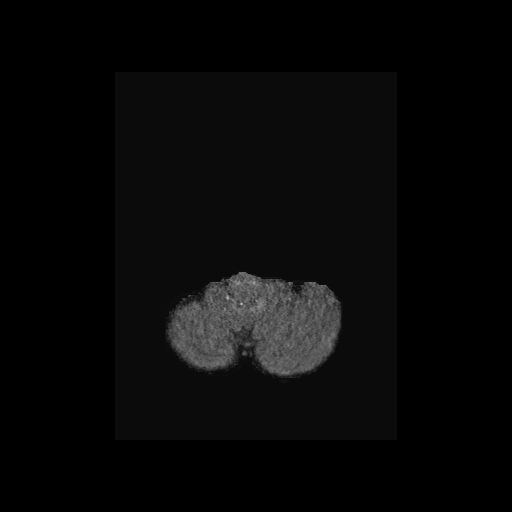

In [52]:
if JUST_TEST:
    TEST_DIR = f"{OUT_DIR}/preprocess_{DATASET_NAME}/test"
    #Extract the first example
    img_example = np.load(
        f"{OUT_DIR}/preprocess_{DATASET_NAME}/test/{os.listdir(TEST_DIR)[150]}", allow_pickle=True
    ).item()

img_example, msk_example = img_example["data"][:,:,0], img_example["mask"]

msk_example = np.argmax(msk_example, axis=-1)

display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)

In [47]:
print_bold("DONE: Preprocessing completed (OUTPUT: {})".format(OUT_DIR))

DONE: Preprocessing completed (OUTPUT: /data/falcetta/LONDON_TEST/OUT)


In [60]:
import os
AAA = '/data/galati/brain_data/ITKTubeTK/fold1/imagesTs_NNUNET'

for imgAAA in os.listdir(AAA):
    if imgAAA.endswith('.nii.gz') and '0000' not in imgAAA:
        # Rename the images
        print(f"Renaming {imgAAA} to {imgAAA.replace('.nii.gz', '_0000.nii.gz')}")
        os.rename(os.path.join(AAA, imgAAA), os.path.join(AAA, imgAAA.replace('.nii.gz', '_0000.nii.gz')))

Renaming Normal001-MRA.nii.gz to Normal001-MRA_0000.nii.gz
Renaming Normal002-MRA.nii.gz to Normal002-MRA_0000.nii.gz
Renaming Normal003-MRA.nii.gz to Normal003-MRA_0000.nii.gz
Renaming Normal004-MRA.nii.gz to Normal004-MRA_0000.nii.gz
Renaming Normal005-MRA.nii.gz to Normal005-MRA_0000.nii.gz
Renaming Normal006-MRA.nii.gz to Normal006-MRA_0000.nii.gz
Renaming Normal007-MRA.nii.gz to Normal007-MRA_0000.nii.gz
Renaming Normal008-MRA.nii.gz to Normal008-MRA_0000.nii.gz
Renaming Normal009-MRA.nii.gz to Normal009-MRA_0000.nii.gz
Renaming Normal010-MRA.nii.gz to Normal010-MRA_0000.nii.gz
Renaming Normal011-MRA.nii.gz to Normal011-MRA_0000.nii.gz
Renaming Normal012-MRA.nii.gz to Normal012-MRA_0000.nii.gz
Renaming Normal013-MRA.nii.gz to Normal013-MRA_0000.nii.gz
Renaming Normal014-MRA.nii.gz to Normal014-MRA_0000.nii.gz
Renaming Normal015-MRA.nii.gz to Normal015-MRA_0000.nii.gz
Renaming Normal016-MRA.nii.gz to Normal016-MRA_0000.nii.gz
Renaming Normal017-MRA.nii.gz to Normal017-MRA_0000.nii.